In [22]:
import pandas as pd
from datetime import datetime, timedelta, date
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA, KernelPCA
import patsy

In [2]:
num_folds = 10

for i in range(1, num_folds + 1):
    # Reading train data
    file_path = f'Proj2_Data/fold_{i}/train.csv'
    train = pd.read_csv(file_path)

    # Reading test data
    file_path = f'Proj2_Data/fold_{i}/test.csv'
    test = pd.read_csv(file_path)

    # Define start and end dates based on test data
    start_last_year = pd.to_datetime(test['Date'].min()) - timedelta(days=375)
    end_last_year = pd.to_datetime(test['Date'].max()) - timedelta(days=350)

    # Filter train data based on the defined dates and compute 'Wk' column
    tmp_train = train[(train['Date'] > str(start_last_year)) 
                      & (train['Date'] < str(end_last_year))].copy()
    tmp_train['Date'] = pd.to_datetime(tmp_train['Date'])  
    tmp_train['Wk'] = tmp_train['Date'].dt.isocalendar().week
    tmp_train.rename(columns={'Weekly_Sales': 'Weekly_Pred'}, inplace=True)
    tmp_train.drop(columns=['Date', 'IsHoliday'], inplace=True)

    # Compute 'Wk' column for test data
    test['Date'] = pd.to_datetime(test['Date'])
    test['Wk'] = test['Date'].dt.isocalendar().week

    # Left join with the tmp_train data
    test_pred = test.merge(tmp_train, on=['Dept', 'Store', 'Wk'], how='left').drop(columns=['Wk'])
    print(test_pred.columns)

    # Fill NaN values with 0 for the Weekly_Pred column
    test_pred['Weekly_Pred'].fillna(0, inplace=True)

    # Save the output to CSV
    file_path = f'Proj2_Data/fold_{i}/mypred2.csv'
    test_pred.to_csv(file_path, index=False)

Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')
Index(['Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Pred'], dtype='object')


In [3]:
test_pred_simple = test_pred
test_pred

,Store,Dept,Date,IsHoliday,Weekly_Pred
0,1,1,2012-09-07,True,17746.68
1,1,1,2012-09-14,False,18535.48
2,1,1,2012-09-21,False,17859.30
3,1,1,2012-09-28,False,18337.68
4,1,1,2012-10-05,False,20797.58
...,...,...,...,...,...
23724,45,98,2012-09-28,False,727.05
23725,45,98,2012-10-05,False,894.98
23726,45,98,2012-10-12,False,996.40
23727,45,98,2012-10-19,False,1058.84


In [4]:
def myeval():
    file_path = 'Proj2_Data/test_with_label.csv'
    test_with_label = pd.read_csv(file_path)
    num_folds = 10
    wae = []

    for i in range(num_folds):
        file_path = f'Proj2_Data/fold_{i+1}/test.csv'
        test = pd.read_csv(file_path)
        test = test.drop(columns=['IsHoliday']).merge(test_with_label, on=['Date', 'Store', 'Dept'])

        file_path = f'Proj2_Data/fold_{i+1}/mypred2.csv'
        test_pred = pd.read_csv(file_path)

        # Left join with the test data
        new_test = test_pred.merge(test, on=['Date', 'Store', 'Dept'], how='left')

        # Compute the Weighted Absolute Error
        actuals = new_test['Weekly_Sales']
        preds = new_test['Weekly_Pred']
        weights = new_test['IsHoliday_x'].apply(lambda x: 5 if x else 1)
        wae.append(sum(weights * abs(actuals - preds)) / sum(weights))

    return wae

In [5]:
wae = myeval()
for value in wae:
    print(f"\t{value:.3f}")
print("Avg: ",f"{sum(wae) / len(wae):.3f}")


	2262.422
	1787.081
	1779.052
	1716.117
	2400.395
	1696.900
	2086.967
	1750.283
	1719.887
	1680.956
Avg:  1888.006


In [206]:
train.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

In [208]:
def preprocess(data):
    tmp = pd.to_datetime(data['Date'])
    data['Store'] = data['Store'].astype('int64')
    data['Dept'] = data['Dept'].astype('int64')
    data['Wk'] = tmp.dt.isocalendar().week
    data['Yr'] = tmp.dt.year
    data['Yr2'] = tmp.dt.year * tmp.dt.year
    data['Wk'] = pd.Categorical(data['Wk'], categories=[i for i in range(1, 53)])  # 52 weeks 
    if 'IsHoliday' in data.columns:
        data['IsHoliday'] = data['IsHoliday'].apply(int)
    return data

def clean_column_names(df):
    cols = []
    for i in df.columns:
        cols.append(i.replace("[", "").replace("]", ""))
    df.columns = cols
    #print(df.columns)
    return df

In [9]:
test_pred = pd.read_csv(f'Proj2_Data/fold_5/mypred_copy.csv')
if i==5:
    test_pred1 = post_process(test_pred)
#test_pred1 #.to_csv(f'Proj2_Data/fold_5/mypred.csv', index=False)

In [200]:
num_folds = 10

for i in range(1, 2): #num_folds + 1): #(5, 6)
    print("Fold ", i)
    # Reading train data
    file_path = f'Proj2_Data/fold_{i}/train.csv'
    train = pd.read_csv(file_path)

    # Reading test data
    file_path = f'Proj2_Data/fold_{i}/test.csv'
    test = pd.read_csv(file_path)

    # pre-allocate a pd to store the predictions
    test_pred = pd.DataFrame()

    train_pairs = train[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    test_pairs = test[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    unique_pairs = pd.merge(train_pairs, test_pairs, how = 'inner', on =['Store', 'Dept'])

    train_split = unique_pairs.merge(train, on=['Store', 'Dept'], how='left')
    train_split = preprocess(train_split)
    y, X = patsy.dmatrices('Weekly_Sales ~ Weekly_Sales + Store + Dept + Yr + Yr2 + Wk', 
                           data = train_split, 
                           return_type='dataframe')
    print(X.columns)
    break
    train_split = dict(tuple(X.groupby(['Store', 'Dept'])))


    test_split = unique_pairs.merge(test, on=['Store', 'Dept'], how='left')
    test_split = preprocess(test_split)
    y, X = patsy.dmatrices('Yr ~ Store + Dept + Yr + Yr2 + Wk', #'Yr ~ Store + Dept + Yr  + Wk'
                           data = test_split, 
                           return_type='dataframe')
    X['Date'] = test_split['Date']
    
    test_split = dict(tuple(X.groupby(['Store', 'Dept'])))
    
    keys = list(train_split)

    for key in keys:
        X_train = train_split[key]
        X_test = test_split[key]
        

        Y = X_train['Weekly_Sales']
        X_train = X_train.drop(['Weekly_Sales','Store', 'Dept'], axis=1)

        cols_to_drop = X_train.columns[(X_train == 0).all()]
        
        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        #print(X_train.columns)
        #break
        cols_to_drop = []
        for ii in range(len(X_train.columns) - 1, 1, -1):  # Start from the last column and move backward
            col_name = X_train.columns[ii]
            # Extract the current column and all previous columns
            tmp_Y = X_train.iloc[:, ii].values
            tmp_X = X_train.iloc[:, :ii].values

            coefficients, residuals, rank, s = np.linalg.lstsq(tmp_X, tmp_Y, rcond=None)
            if np.sum(residuals) < 1e-10:
                    cols_to_drop.append(col_name)

        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        model = sm.OLS(Y, X_train).fit()
        mycoef = model.params.fillna(0)
        
        tmp_pred = X_test[['Store', 'Dept', 'Date']]
        X_test = X_test.drop(['Store', 'Dept', 'Date'], axis=1)
        
            
        tmp_pred['Weekly_Pred'] = np.dot(X_test, mycoef)
        test_pred = pd.concat([test_pred, tmp_pred], ignore_index=True)
        if 'IsHoliday' in test_pred.columns:
            test_pred = test_pred.drop(columns="IsHoliday")
        test_pred = pd.merge(test_pred, test, on=['Store', 'Dept', 'Date'])

    test_pred['Weekly_Pred'].fillna(0, inplace=True)
    file_path = f'Proj2_Data/fold_{i}/mypred.csv'
    test_pred.to_csv(file_path, index=False)

Fold  1
Index(['Intercept', 'Wk[T.2]', 'Wk[T.3]', 'Wk[T.4]', 'Wk[T.5]', 'Wk[T.6]',
       'Wk[T.7]', 'Wk[T.8]', 'Wk[T.9]', 'Wk[T.10]', 'Wk[T.11]', 'Wk[T.12]',
       'Wk[T.13]', 'Wk[T.14]', 'Wk[T.15]', 'Wk[T.16]', 'Wk[T.17]', 'Wk[T.18]',
       'Wk[T.19]', 'Wk[T.20]', 'Wk[T.21]', 'Wk[T.22]', 'Wk[T.23]', 'Wk[T.24]',
       'Wk[T.25]', 'Wk[T.26]', 'Wk[T.27]', 'Wk[T.28]', 'Wk[T.29]', 'Wk[T.30]',
       'Wk[T.31]', 'Wk[T.32]', 'Wk[T.33]', 'Wk[T.34]', 'Wk[T.35]', 'Wk[T.36]',
       'Wk[T.37]', 'Wk[T.38]', 'Wk[T.39]', 'Wk[T.40]', 'Wk[T.41]', 'Wk[T.42]',
       'Wk[T.43]', 'Wk[T.44]', 'Wk[T.45]', 'Wk[T.46]', 'Wk[T.47]', 'Wk[T.48]',
       'Wk[T.49]', 'Wk[T.50]', 'Wk[T.51]', 'Wk[T.52]', 'Weekly_Sales', 'Store',
       'Dept', 'Yr', 'Yr2'],
      dtype='object')


num_folds = 10

for i in range(1, num_folds + 1): #(5, 6)
    print("Fold ", i)
    file_path = f'Proj2_Data/fold_{i}/mypred.csv'
    test_pred = pd.read_csv(file_path)
    test_pred['Date'] = pd.to_datetime(test_pred['Date'])  
    test_pred = pd.merge(test_pred.drop(columns="IsHoliday"), test, on=['Store', 'Dept', 'Date'])
    test_pred['Weekly_Pred'].fillna(0, inplace=True)
    #file_path = f'Proj2_Data/fold_{i}/mypred.csv'
    test_pred.to_csv(file_path, index=False)

#LinearRegression
mycoef

#sm.OLS
mycoef

In [ ]:
test_pred = pd.read_csv(f'Proj2_Data/fold_5/mypred2.csv')
if i==5:
    test_pred1 = test_pred #post_process(test_pred)
test_pred1.to_csv(f'Proj2_Data/fold_5/mypred.csv', index=False)

test = pd.read_csv(f'Proj2_Data/fold_5/mypred.csv')
test #post_process

In [141]:
def myeval():
    file_path = 'Proj2_Data/test_with_label.csv'
    test_with_label = pd.read_csv(file_path)
    num_folds = 10
    wae = []

    for i in range(num_folds):
        file_path = f'Proj2_Data/fold_{i+1}/test.csv'
        test = pd.read_csv(file_path)
        test = test.drop(columns=['IsHoliday']).merge(test_with_label, on=['Date', 'Store', 'Dept'])

        file_path = f'Proj2_Data/fold_{i+1}/mypred.csv'
        test_pred = pd.read_csv(file_path)

        # Left join with the test data
        new_test = test_pred.merge(test, on=['Date', 'Store', 'Dept'], how='left')

        # Compute the Weighted Absolute Error
        actuals = new_test['Weekly_Sales']
        preds = new_test['Weekly_Pred']
        weights = new_test['IsHoliday_x'].apply(lambda x: 5 if x else 1)
        wae.append(sum(weights * abs(actuals - preds)) / sum(weights))

    return wae

In [143]:
wae = myeval()
for value in wae:
    print(f"\t{value:.3f}")
print("Avg: ",f"{sum(wae) / len(wae):.3f}")
#fold 1 is 2049.347

	2049.347
	1467.113
	1446.882
	1595.628
	2189.342
	1675.221
	1643.953
	1364.648
	1358.588
	1344.983
Avg:  1613.571


## Post

In [20]:
def post(df):
    df['Date'] = pd.to_datetime(df['Date'])  
    df['Wk'] = df['Date'].dt.isocalendar().week
    #tmp = df[df['Wk']==51]
    return df

In [219]:
def findVal(test_pred):
    file_path = 'Proj2_Data/test_with_label.csv'
    test_with_label = pd.read_csv(file_path)

    i=4
    file_path = f'Proj2_Data/fold_{i+1}/test.csv'
    test = pd.read_csv(file_path)
    test = test.drop(columns=['IsHoliday']).merge(test_with_label, on=['Date', 'Store', 'Dept'])
    test['Date'] = pd.to_datetime(test['Date'])  
    

    # Left join with the test data
    test_pred['Date'] = pd.to_datetime(test_pred['Date'])  
    new_test = test_pred.merge(test, on=['Date', 'Store', 'Dept'], how='left')

    # Compute the Weighted Absolute Error
    actuals = new_test['Weekly_Sales']
    preds = new_test['Weekly_Pred']
    weights = new_test['IsHoliday_x'].apply(lambda x: 5 if x else 1)
    return (sum(weights * abs(actuals - preds)) / sum(weights))


In [235]:
test_pred = pd.read_csv(f'Proj2_Data/fold_5/mypred_copy.csv')
print(test_pred.shape)
i=4
if i==4:
    test_pred1 = test_pred #post(test_pred)

num=100
params = [0.016, 0.018, 0.020] #[x/num for x in range(num//20)] #
vals = []
#params = [0.011], 

for r in params:
    test_pred1['Date'] = pd.to_datetime(test_pred1['Date'])  
    test_pred1['Wk'] = test_pred1['Date'].dt.isocalendar().week
    tmp = test_pred1[test_pred1['Wk']==51].copy()
    tmp['Adjustment'] = tmp['Weekly_Pred']*r
    tmp = tmp[['Store', 'Dept', 'Wk', 'Adjustment']]
    
    # Subtract from week 51
    test_pred1 = pd.merge(test_pred1, tmp, on=['Store', 'Dept', 'Wk'], how='left')
    test_pred1 = test_pred1.fillna(0)
    test_pred1['Weekly_Pred'] = test_pred1['Weekly_Pred'] - test_pred1['Adjustment']
    #print(test_pred1.head(5))
    test_pred1 = test_pred1[['Store', 'Dept', 'Date', 'Weekly_Pred', 'Wk', 'IsHoliday']]
    

    
    # Add to week 52
    tmp['Wk'] = 52 
    test_pred1 = pd.merge(test_pred1, tmp, on=['Store', 'Dept', 'Wk'], how='left')
    test_pred1 = test_pred1.fillna(0)
    test_pred1['Weekly_Pred'] = test_pred1['Weekly_Pred'] + test_pred1['Adjustment']
    test_pred1 = test_pred1[['Store', 'Dept', 'Date', 'Weekly_Pred', 'IsHoliday']]
    '''
    '''
    if r%10==0:
        print(r)

    test = pd.read_csv(f'Proj2_Data/fold_5/test.csv')
    test['Date'] = pd.to_datetime(test['Date'])  
    test_pred1['Date'] = pd.to_datetime(test_pred1['Date'])  
    test_pred1 = pd.merge(test_pred1.drop(columns='IsHoliday'), test, on=['Store', 'Dept', 'Date'])
    #print(test_pred1.shape)
    test_pred1.to_csv(f'Proj2_Data/fold_5/mypred.csv', index=False)
    vals.append([r, findVal(test_pred1)])

vals = np.array(vals)
print(vals)

(26838, 5)
[[1.60000000e-02 2.25445102e+03]
 [1.80000000e-02 2.20226269e+03]
 [2.00000000e-02 2.17045362e+03]]


<AxesSubplot:xlabel='0'>

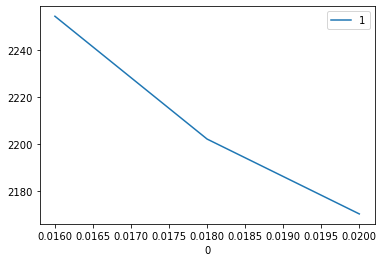

In [236]:
#vals = vals[:10]
pd.DataFrame(vals).plot(x=0, y=1)

In [237]:
wae = myeval()
for value in wae:
    print(f"\t{value:.3f}")
print("Avg: ",f"{sum(wae) / len(wae):.3f}")
#2334.678 for week 5 without post
#2189.342 for week 5

	1945.900
	1364.163
	1384.109
	1528.781
	2170.454
	1638.096
	1614.847
	1355.272
	1337.454
	1334.495
Avg:  1567.357


## PCA + Linear Regression

In [193]:
train

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
164110,45,98,2011-01-28,77.00,False
164111,45,98,2011-02-04,57.25,False
164112,45,98,2011-02-11,388.80,True
164113,45,98,2011-02-18,284.50,False


In [106]:
# Filter rows where Dept is equal to i
filtered_df = train[train['Dept'] == 43]

# Select only the columns 'Store', 'Date', and 'Weekly_Sales'
selected_columns = filtered_df[['Store', 'Date', 'Weekly_Sales']]

# Pivot table to spread 'Store' values into columns, with 'Weekly_Sales' as values
df_dept_ts = selected_columns.pivot(index='Date', columns='Store', values='Weekly_Sales').reset_index()

df_dept_arr = np.array(df_dept_ts.drop(columns='Date'))
df_dept_arr[np.isnan(df_dept_arr)] = 0

pca = PCA(n_components=8, random_state=42)
kernel_pca = KernelPCA(
    n_components=8,
    kernel="rbf",
    gamma=1e-3,
    fit_inverse_transform=True,
    alpha=5e-3,
    random_state=42,
)
'''
pca.fit(df_dept_arr)
reconstructed_pca = pca.inverse_transform(pca.transform(df_dept_arr))
df_pca_i = pd.concat([df_dept_ts[['Date']], pd.DataFrame(reconstructed_pca, columns=[x for x in range(1, 46)])], axis=1)
df_pca = pd.concat([df_pca, df_pca_i])

'''
df_dept_ts['Dept'] = 43
df_dept_ts

Store,Date,14,28,Dept
0,2010-02-12,0.25,NaN,43
1,2010-04-09,NaN,1.0,43
2,2010-08-27,NaN,0.5,43


In [214]:
def getPCA(df):
    cols = ['Date', 'Dept'] + ([i for i in range(1, 46)])
    df_pca = pd.DataFrame(columns=cols)
    for i in df['Dept'].unique():
        # Filter rows where Dept is equal to i
        filtered_df = df[df['Dept'] == i]
        
        # Select only the columns 'Store', 'Date', and 'Weekly_Sales'
        selected_columns = filtered_df[['Store', 'Date', 'Weekly_Sales']]

        # Pivot table to spread 'Store' values into columns, with 'Weekly_Sales' as values
        df_dept_ts = selected_columns.pivot(index='Date', columns='Store', values='Weekly_Sales').reset_index()

        df_dept_arr = np.array(df_dept_ts.drop(columns='Date'))
        df_dept_arr[np.isnan(df_dept_arr)] = 0
        
        num = min(min(df_dept_ts.drop(columns='Date').shape), 8)

        pca = PCA(n_components=num, random_state=42)
        kernel_pca = KernelPCA(
            n_components=num,
            kernel="rbf",
            gamma=1e-3,
            fit_inverse_transform=True,
            alpha=5e-3,
            random_state=42,
        )

        pca.fit(df_dept_arr)
        reconstructed_pca = pca.inverse_transform(pca.transform(df_dept_arr))
        df_dept_ts['Dept'] = i
        df_pca_i = pd.concat([df_dept_ts[['Date', 'Dept']], pd.DataFrame(reconstructed_pca, columns=filtered_df['Store'].unique())], axis=1)
        df_pca = pd.concat([df_pca, df_pca_i])
        #break
    return df_pca

In [216]:
num_folds = 10

for i in range(1, num_folds + 1): #(5, 6)
    print("Fold ", i)
    # Reading train data
    file_path = f'Proj2_Data/fold_{i}/train.csv'
    train = pd.read_csv(file_path)

    train_pca = getPCA(train)
    train = train_pca.melt(id_vars=['Date', 'Dept']).dropna()
    train.columns = ['Date', 'Dept', 'Store', 'Weekly_Sales']

    # Reading test data
    file_path = f'Proj2_Data/fold_{i}/test.csv'
    test = pd.read_csv(file_path)

    # pre-allocate a pd to store the predictions
    test_pred = pd.DataFrame()

    train_pairs = train[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    test_pairs = test[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    unique_pairs = pd.merge(train_pairs, test_pairs, how = 'inner', on =['Store', 'Dept'])

    train_split = unique_pairs.merge(train, on=['Store', 'Dept'], how='left')
    train_split = preprocess(train_split)
    y, X = patsy.dmatrices('Weekly_Sales ~ Weekly_Sales + Store + Dept + Yr + Yr2 + Wk', 
                           data = train_split, 
                           return_type='dataframe')
    #print(X.columns)
    #break
    train_split = dict(tuple(X.groupby(['Store', 'Dept'])))


    test_split = unique_pairs.merge(test, on=['Store', 'Dept'], how='left')
    test_split = preprocess(test_split)
    y, X = patsy.dmatrices('Yr ~ Store + Dept + Yr + Yr2 + Wk', #'Yr ~ Store + Dept + Yr  + Wk'
                           data = test_split, 
                           return_type='dataframe')
    X['Date'] = test_split['Date']
    
    test_split = dict(tuple(X.groupby(['Store', 'Dept'])))
    
    keys = list(train_split)

    for key in keys:
        X_train = train_split[key]
        X_test = test_split[key]
        

        Y = X_train['Weekly_Sales']
        X_train = X_train.drop(['Weekly_Sales','Store', 'Dept'], axis=1)

        cols_to_drop = X_train.columns[(X_train == 0).all()]
        
        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        #print(X_train.columns)
        #break
        cols_to_drop = []
        for ii in range(len(X_train.columns) - 1, 1, -1):  # Start from the last column and move backward
            col_name = X_train.columns[ii]
            # Extract the current column and all previous columns
            tmp_Y = X_train.iloc[:, ii].values
            tmp_X = X_train.iloc[:, :ii].values

            coefficients, residuals, rank, s = np.linalg.lstsq(tmp_X, tmp_Y, rcond=None)
            if np.sum(residuals) < 1e-10:
                    cols_to_drop.append(col_name)

        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        model = sm.OLS(Y, X_train).fit()
        mycoef = model.params.fillna(0)
        
        tmp_pred = X_test[['Store', 'Dept', 'Date']]
        X_test = X_test.drop(['Store', 'Dept', 'Date'], axis=1)
        
            
        tmp_pred['Weekly_Pred'] = np.dot(X_test, mycoef)
        test_pred = pd.concat([test_pred, tmp_pred], ignore_index=True)
        if 'IsHoliday' in test_pred.columns:
            test_pred = test_pred.drop(columns="IsHoliday")
        test_pred = pd.merge(test_pred, test, on=['Store', 'Dept', 'Date'])

    test_pred['Weekly_Pred'].fillna(0, inplace=True)
    file_path = f'Proj2_Data/fold_{i}/mypred.csv'
    test_pred.to_csv(file_path, index=False)

Fold  1
Fold  2
Fold  3
Fold  4
Fold  5
Fold  6
Fold  7
Fold  8
Fold  9
Fold  10


reconstructed_pca

train_dept_arr

num_folds = 10

for i in range(1, num_folds + 1): #(5, 6)
    print("Fold ", i)
    # Reading train data
    train = 

    # Reading test data
    file_path = f'Proj2_Data/fold_{i}/test.csv'
    test = pd.read_csv(file_path)

    # pre-allocate a pd to store the predictions
    test_pred = pd.DataFrame()

    train_pairs = train[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    test_pairs = test[['Store', 'Dept']].drop_duplicates(ignore_index=True)
    unique_pairs = pd.merge(train_pairs, test_pairs, how = 'inner', on =['Store', 'Dept'])

    train_split = unique_pairs.merge(train, on=['Store', 'Dept'], how='left')
    train_split = preprocess(train_split)
    y, X = patsy.dmatrices('Weekly_Sales ~ Weekly_Sales + Store + Dept + Yr + Yr2 + Wk', 
                           data = train_split, 
                           return_type='dataframe')
    train_split = dict(tuple(X.groupby(['Store', 'Dept'])))


    test_split = unique_pairs.merge(test, on=['Store', 'Dept'], how='left')
    test_split = preprocess(test_split)
    y, X = patsy.dmatrices('Yr ~ Store + Dept + Yr + Yr2 + Wk', #'Yr ~ Store + Dept + Yr  + Wk'
                           data = test_split, 
                           return_type='dataframe')
    X['Date'] = test_split['Date']
    
    test_split = dict(tuple(X.groupby(['Store', 'Dept'])))
    
    keys = list(train_split)

    for key in keys:
        X_train = train_split[key]
        X_test = test_split[key]
        

        Y = X_train['Weekly_Sales']
        X_train = X_train.drop(['Weekly_Sales','Store', 'Dept'], axis=1)

        cols_to_drop = X_train.columns[(X_train == 0).all()]
        
        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        #print(X_train.columns)
        #break
        cols_to_drop = []
        for ii in range(len(X_train.columns) - 1, 1, -1):  # Start from the last column and move backward
            col_name = X_train.columns[ii]
            # Extract the current column and all previous columns
            tmp_Y = X_train.iloc[:, ii].values
            tmp_X = X_train.iloc[:, :ii].values

            coefficients, residuals, rank, s = np.linalg.lstsq(tmp_X, tmp_Y, rcond=None)
            if np.sum(residuals) < 1e-10:
                    cols_to_drop.append(col_name)

        X_train = X_train.drop(columns=cols_to_drop)
        X_test = X_test.drop(columns=cols_to_drop)

        #Use LinearRegression from sklearn instead
        ##model = LinearRegression().fit(X_train, Y) #tol=0.01
        #mycoef = model.coef_ #.fillna(0)
        model = sm.OLS(Y, X_train).fit()
        mycoef = model.params.fillna(0)
        
        tmp_pred = X_test[['Store', 'Dept', 'Date']]
        X_test = X_test.drop(['Store', 'Dept', 'Date'], axis=1)
        
            
        tmp_pred['Weekly_Pred'] = np.dot(X_test, mycoef)
        test_pred = pd.concat([test_pred, tmp_pred], ignore_index=True)
        if 'IsHoliday' in test_pred.columns:
            test_pred = test_pred.drop(columns="IsHoliday")
        test_pred = pd.merge(test_pred, test, on=['Store', 'Dept', 'Date'])

    test_pred['Weekly_Pred'].fillna(0, inplace=True)
    file_path = f'Proj2_Data/fold_{i}/mypred.csv'
    test_pred.to_csv(file_path, index=False)

In [217]:
def myeval():
    file_path = 'Proj2_Data/test_with_label.csv'
    test_with_label = pd.read_csv(file_path)
    num_folds = 10
    wae = []

    for i in range(num_folds):
        file_path = f'Proj2_Data/fold_{i+1}/test.csv'
        test = pd.read_csv(file_path)
        test = test.drop(columns=['IsHoliday']).merge(test_with_label, on=['Date', 'Store', 'Dept'])

        file_path = f'Proj2_Data/fold_{i+1}/mypred.csv'
        test_pred = pd.read_csv(file_path)

        # Left join with the test data
        new_test = test_pred.merge(test, on=['Date', 'Store', 'Dept'], how='left')

        # Compute the Weighted Absolute Error
        actuals = new_test['Weekly_Sales']
        preds = new_test['Weekly_Pred']
        weights = new_test['IsHoliday_x'].apply(lambda x: 5 if x else 1)
        wae.append(sum(weights * abs(actuals - preds)) / sum(weights))

    return wae

wae = myeval()
for value in wae:
    print(f"\t{value:.3f}")
print("Avg: ",f"{sum(wae) / len(wae):.3f}")


	1945.900
	1364.163
	1384.109
	1528.781
	2320.452
	1638.096
	1614.847
	1355.272
	1337.454
	1334.495
Avg:  1582.357


i=1;
train = pd.read_csv(f'Proj2_Data/fold_{i}/train.csv')
test = pd.read_csv(f'Proj2_Data/fold_{i}/test.csv')
train[['Date', 'Weekly_Sales']].groupby('Date').sum().plot()

train[['Date', 'Weekly_Sales']].groupby('Date').sum().plot()

import matplotlib.pyplot as plt
li = []
for i in range(1, 11):
    test = pd.read_csv(f'Proj2_Data/fold_{i}/test.csv')
    test['Date'] = pd.to_datetime(test['Date'])  
    test['Wk'] = test['Date'].dt.isocalendar().week
    #test[pd.to_datetime(test['Date']) > pd.to_datetime(date(2012, 1, 19))]
    #print("Fold: ", i)
    #print("Holiday", test[['IsHoliday']][test['IsHoliday']==True].count()[0])
    #print("Score by regression: ", wae[i-1])
    #li.append([test[['IsHoliday']][test['IsHoliday']==True].count()[0], wae[i-1]])
    #print()
    #li.append([test[['IsHoliday']][test['IsHoliday']==True].count()[0], wae[i-1]])

    #li = pd.DataFrame(li)
    test['key'] = test['IsHoliday'].astype('int') * 100
    #test['Date'] = pd.to_datetime(test['Date']).dt.month 


# | (df['First_name'] == 'Jay'